# K-nearest neighbour

In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [11]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

diff=pd.DataFrame({'Actual data':y_test,"predicted data":prediction})
diff

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


,Actual data,predicted data
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [12]:
diff.to_excel('diabetes_data.xlsx')

In [13]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


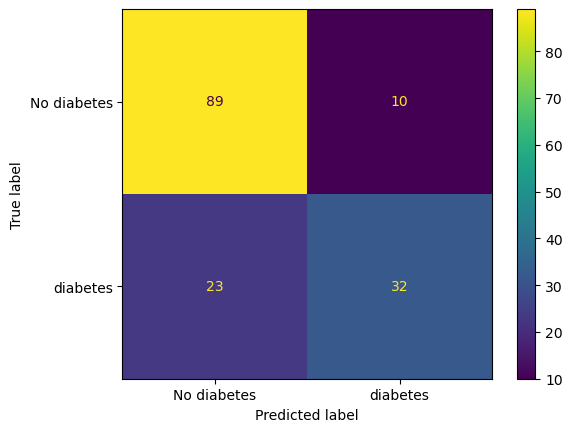

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No diabetes","diabetes"])
cm_display.plot()
plt.show()

In [17]:
tn=cm[0][0]
fp=cm[0][1]
fn=cm[1][0]
tp=cm[1][1]
print("TN:",tn,",FP:",fp,"FN:",fn,"TP:",tp)

TN: 89 ,FP: 10 FN: 23 TP: 32


In [29]:
from sklearn.metrics import accuracy_score
print("ACcuracy score:",accuracy_score(y_test,prediction))

accuracy=(tn+tp)/(tn+fn+fp+tp)
print("accuracy percent:",accuracy*100,"%")

ACcuracy score: 0.7857142857142857
accuracy percent: 78.57142857142857 %


In [23]:
errorRate=(fn+fp)/(tn+fn+fp+tp)
print("Error rate:",errorRate*100,"%")

#or

from sklearn.metrics import accuracy_score
print("ACcuracy score:",1-accuracy_score(y_test,prediction))

Error rate: 21.428571428571427 %
ACcuracy score: 0.2142857142857143


In [31]:
sensitivity=tp/(tp+fn)
print("sensitivity:",sensitivity*100,"%")

specificity=tn/(tn+fp)
print("specificity:",specificity*100,"%")

#OR

from sklearn.metrics import recall_score
print("sensitivity:",recall_score(y_test,prediction))
print("specificity:",recall_score(y_test,prediction,pos_label=0))

sensitivity: 58.18181818181818 %
specificity: 89.8989898989899 %
sensitivity: 0.5818181818181818
specificity: 0.898989898989899


In [34]:
Precision_Score=tp/(tp+fp)
print("Precision Score(for Positive):",Precision_Score)

from sklearn.metrics import precision_score
print("Precision Score(for Positive):",precision_score(y_test,prediction))
print("Precision Score(for Negative):",precision_score(y_test,prediction,pos_label=0))

Precision Score(for Positive): 0.7619047619047619
Precision Score(for Positive): 0.7619047619047619
Precision Score(for Negative): 0.7946428571428571


In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
accuracy=[]
for i in range(1,31):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)    
    accuracy.append(accuracy_score(y_test,prediction))
print(accuracy)

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663, 0.7792207792207793]


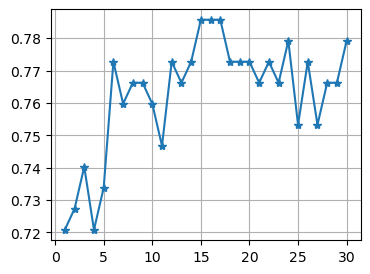

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(range(1,31),accuracy,marker="*")
plt.grid(True)
plt.show()

In [40]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [44]:
x=df[["Height","Wight"]]
y=df["Size"]
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [50]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=3)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({'Actual data':y,"predicted data":prediction})
diff

from sklearn.metrics import accuracy_score
print("ACcuracy score:",accuracy_score(y,prediction))

['M' 'M' 'M' 'M' 'M' 'M' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']
ACcuracy score: 1.0


[[11  0]
 [ 0  7]]


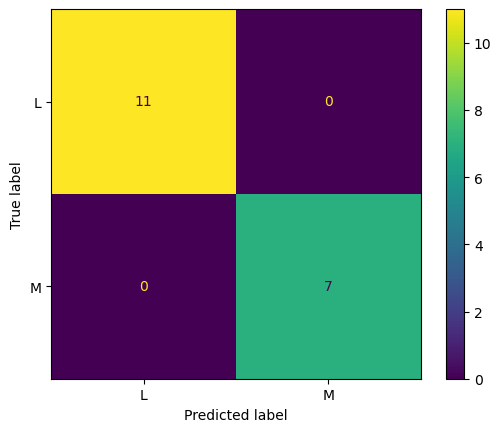

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["L","M"])
cm_display.plot()
plt.show()

In [55]:
from sklearn.metrics import recall_score
print("sensitivity:",recall_score(y,prediction,pos_label="M"))
print("specificity:",recall_score(y,prediction,pos_label="L"))

sensitivity: 1.0
specificity: 1.0


In [56]:
import pandas as pd
df=pd.read_csv("aptitudecommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhuvan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Speaker
4,dinesh,8,6.0,Intel
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Leader
8,Govind,8,3.0,Intel
9,Shushant,6,5.5,Speaker


In [57]:
x=df.iloc[:,1:3]
y=df["Class"]
x


,Aptitude,Communication
0,2,5.0
1,2,6.0
2,7,6.0
3,7,2.5
4,8,6.0
5,4,7.0
6,5,3.0
7,3,5.5
8,8,3.0
9,6,5.5


In [63]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=3)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

diff=pd.DataFrame({'Actual data':y,"predicted data":prediction})
diff

from sklearn.metrics import accuracy_score
print("ACcuracy score:",accuracy_score(y,prediction))

['Speaker' 'Speaker' 'Intel' 'Intel' 'Leader' 'Leader' 'Intel' 'Speaker'
 'Intel' 'Intel' 'Intel' 'Leader' 'Intel' 'Leader']
ACcuracy score: 0.5714285714285714


[[4 1 0]
 [1 2 1]
 [2 1 2]]


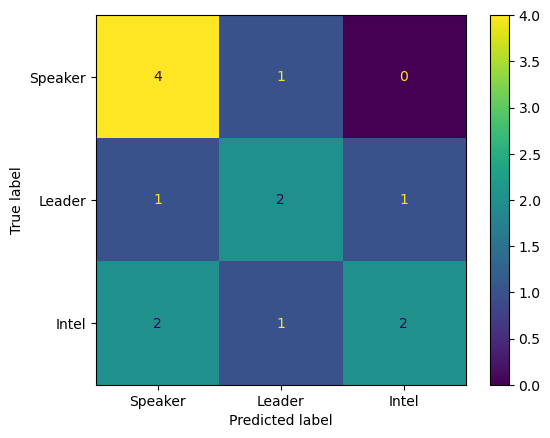

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Speaker","Leader","Intel"])
cm_display.plot()
plt.show()